## 06_scatter_matrix.ipynb

In [92]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [93]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

In [94]:
query = """
        WITH active_users AS (
            SELECT DISTINCT c.uid
            FROM checker c
            JOIN pageviews p ON p.uid = c.uid
            WHERE c.uid LIKE 'user_%'
              AND c.labname != 'project1'
              AND c.status = 'ready'
        ),
        first_commits AS (
            SELECT
                uid,
                labname,
                MIN(timestamp) AS first_ts
            FROM checker
            WHERE uid IN (SELECT uid FROM active_users)
              AND labname != 'project1'
              AND status = 'ready'
            GROUP BY uid, labname
        ),
        avg_diff AS (
            SELECT
                fc.uid,
                AVG((strftime('%s', fc.first_ts) - d.deadlines) / 3600.0) AS avg_diff
            FROM first_commits fc
            JOIN deadlines d ON d.labs = fc.labname
            GROUP BY fc.uid
            HAVING avg_diff IS NOT NULL
        ),
        pv AS (
            SELECT uid, COUNT(*) AS pageviews
            FROM pageviews
            WHERE uid IN (SELECT uid FROM active_users)
            GROUP BY uid
        ),
        cm AS (
            SELECT uid, COUNT(*) AS num_commits
            FROM checker
            WHERE uid IN (SELECT uid FROM active_users)
              AND labname != 'project1'
              AND status = 'ready'
            GROUP BY uid
        )
        SELECT
            a.uid,
            a.avg_diff,
            p.pageviews,
            c.num_commits
        FROM avg_diff a
        JOIN pv p ON p.uid = a.uid
        JOIN cm c ON c.uid = a.uid
        ORDER BY a.uid;
        """

df = pd.read_sql(query, conn)
conn.close()
df

,uid,avg_diff,pageviews,num_commits
0,user_1,-65.119778,28,35
1,user_10,-75.242444,89,13
2,user_14,-159.568796,143,33
3,user_17,-62.207667,47,29
4,user_18,-6.368148,3,4
5,user_19,-99.440417,16,62
6,user_21,-96.111181,10,35
7,user_25,-93.474944,179,43
8,user_28,-86.793833,149,33
9,user_3,-105.738222,317,13


array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

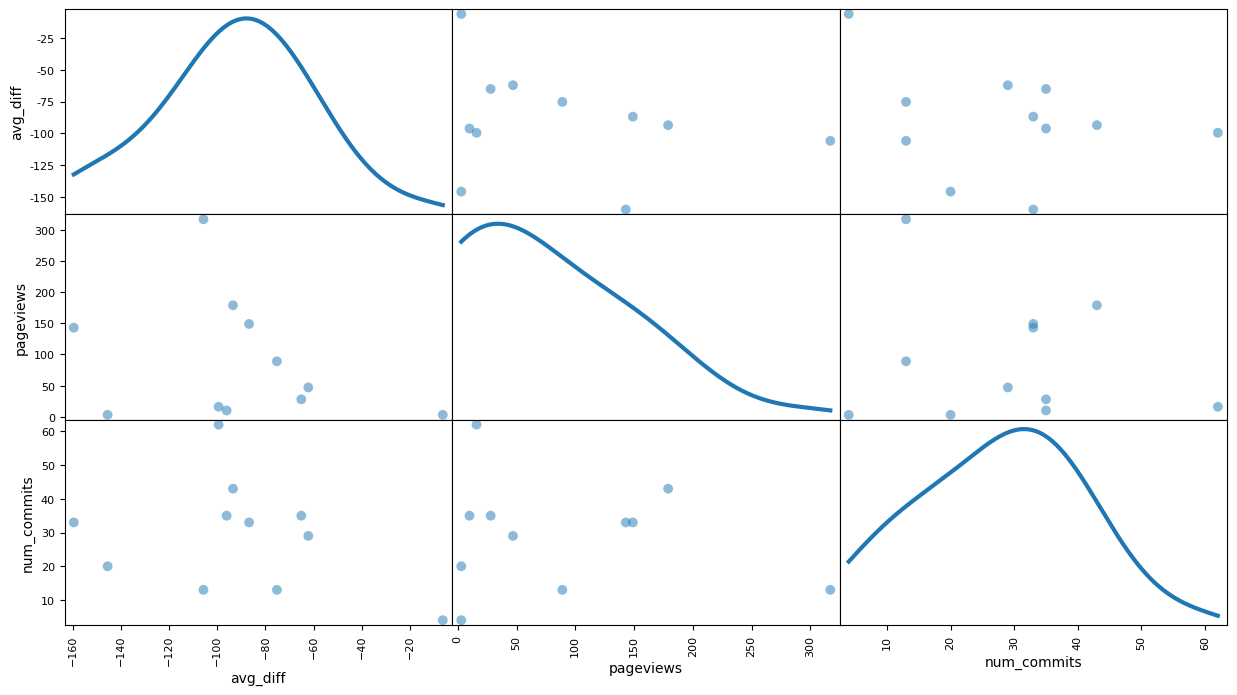

In [95]:
scatter_matrix (
    df[['avg_diff', 'pageviews', 'num_commits']],
    figsize = (15,8),
    diagonal = "kde",
    s=200,
    density_kwds={'linewidth': 3}
)

## "Can we say that if a user has a low number of pageviews, then they likely have a low number of commits?" The answer is yes or no.

no

## "Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline?" The answer is yes or no.

no

## "Can we say that there are many users with a low number of commits and a few with a high number of commits?" The answer is yes or no.

yes

## "Can we say that there are many users with a small average difference and a few with a large average difference?" The answer is yes or no.

no